In [13]:
# goal: detect family in photos

from fx import (
    load_image_file,  
    face_encodings,     # face-recognition/dlib image -> array 
    get_encodings,      # get list of face encodings 
    ensure_lst,
    show,
    # save_encodings
    np,pd
)

results_file='features/faces.parquet'

In [2]:
pics = [
    'labeled_pics/IMG_0210-2016-11-06 211542.JPG',  # should find 2 faces
    'labeled_pics/IMG_0025-2017-12-26 141137.JPG'   # should find 1 face
]
# for p in pics: show(p)

for p in pics:
    img = load_image_file(p)  # uses PIL
    encodings = face_encodings(img)
    print('faces found: ',len(encodings))


faces found:  0
faces found:  0


In [3]:
for p in pics:
    # get_encodings uses opencv instead of PIL
    # and reduces size for speed
    print('faces found: ',len(get_encodings(p)))

faces found:  2
faces found:  1


In [4]:
# curated some pics with just one face to use as labels
def label(pics:list):
    pics = ensure_lst(pics)
    return [
        get_encodings(i)
        [0] # get one & only fac in pic
        for i in pics
    ]

wife = label('labeled_pics/wife.JPG')
me = label(['labeled_pics/me.JPG'])
son = label(['labeled_pics/IMG_0025-2017-12-26 141137.JPG'])
daughter = label([
        'labeled_pics/daughter.JPG',  
        'labeled_pics/daughter1.JPG',
])

print(f'each face encodes to array of {len(wife[0])} length ')

# save_encodings("labeled_embeddings/daughter.npz",daughter)
# save_encodings("labeled_embeddings/me.npz",me)
# save_encodings('labeled_embeddings/son.npz',son)

each face encodes to array of 128 length 


In [5]:
# testing
def face_matches(known_faces,faces,tolerance=.6):
    known_faces=ensure_lst(known_faces)
    faces=ensure_lst(faces)    
    for f in faces:
        # print('face shape',f.shape)
        for dist in np.linalg.norm(known_faces - f, axis=1):
            # print('dist ',dist)
            if dist < tolerance: return 1
    return 0

print('does daughter at 18 months match 3 years? ',face_matches(daughter[0],daughter[1]),'\n')
print('daughter match wife? ',face_matches(daughter,wife),'\n')
print('me match wife? ',face_matches(me,wife))

does daughter at 18 months match 3 years?  1 

daughter match wife?  0 

me match wife?  0


In [6]:
# should match on me & daughter
f = 'labeled_pics/DSC_0010-2018-02-23 065122.JPG'
# show(f)
assert face_matches(daughter,get_encodings(f))
assert face_matches(me,get_encodings(f))
assert not face_matches(wife,get_encodings(f))
print('pass')

pass


In [7]:
# does this pic up son & daughter
f = 'labeled_pics/IMG_0210-2016-11-06 211542.JPG'

# show(f)
assert face_matches(daughter,get_encodings(f))
assert face_matches(son,get_encodings(f))
assert not face_matches(me,get_encodings(f))
assert not face_matches(wife,get_encodings(f))
assert face_matches(wife,get_encodings('labeled_pics/June 2008 035.jpg'))
print('pass')

pass


In [8]:
me_with_beard='labeled_pics/IMG_E1842-2021-09-14 025917.JPG'
assert face_matches(me,get_encodings(me_with_beard))
# assert not face_matches(wife,get_encodings(me_with_beard))  # fail :(
print('done')

done


In [18]:
#correctly matches wife & son
f = '/mnt/4C74F47B74F468DA/Pictures/disney/laurens/IMG_6160.JPG'
# show(f)
assert face_matches(wife,get_encodings(f)) and face_matches(son,get_encodings(f))
print('pass')

pass


In [ ]:
f = "/mnt/4C74F47B74F468DA/Pictures/IMG_1900-2018-05-21 131315.JPG"
# show(f)
assert face_matches(me,get_encodings(f)) and face_matches(daughter,get_encodings(f))

#to do: examine where this matches wife; i don't think it shoudl match her
face_matches(wife,get_encodings(f))

1

In [ ]:
# should match son
/mnt/4C74F47B74F468DA/Pictures/n iphone/2022-01-07 001/Internal Storage/DCIM/100APPLE/IMG_0854.JPG

In [ ]:
def all_matches(f):
    encodings = get_encodings(f)
    return {
        'path': f,
        'wife': face_matches(wife,encodings),
        'daughter': face_matches(daughter,encodings),
        'son': face_matches(son,encodings),
        'me': face_matches(me,encodings),
    }    

# 14 second to do 60 images => 45 minutes for whole

results = []
files = list(
    pd.read_parquet('features/files.parquet')
    # .sample(25)
    .path)
for f in files:
    results.append(all_matches(f))

(
    pd.DataFrame(results)
    .to_parquet(results_file,index=False)
)

del results

In [9]:
(
    pd.read_parquet(results_file)
    .print_shape()
    .sample(10)
)

(13652, 5)


,path,wife,daughter,son,me
13441,/mnt/4C74F47B74F468DA/DCIM/Internal Storage/DC...,0,0,0,0
12655,/mnt/4C74F47B74F468DA/Pictures/n iphone/2022-0...,0,0,0,0
7733,/mnt/4C74F47B74F468DA/Pictures/DSC_0910-2018-0...,0,0,0,0
1391,/mnt/4C74F47B74F468DA/Pictures/IMG_2326-2013-0...,0,0,0,0
3969,/mnt/4C74F47B74F468DA/Pictures/IMG_1965-2017-0...,0,0,0,0
7100,/mnt/4C74F47B74F468DA/Pictures/DSC_0542-2015-0...,0,1,1,0
8528,/mnt/4C74F47B74F468DA/Pictures/DSC_0382-2018-0...,0,1,0,1
8447,/mnt/4C74F47B74F468DA/Pictures/DSC_0338-2014-0...,0,0,0,0
5534,/mnt/4C74F47B74F468DA/Pictures/IMG_5357-2020-0...,0,0,0,0
12882,/mnt/4C74F47B74F468DA/DCIM/201902__/IMG_0386.JPG,0,1,0,1


In [11]:
pd.read_parquet(results_file).wife.sum()
pd.read_parquet(results_file).daughter.sum()
pd.read_parquet(results_file).son.sum()
pd.read_parquet(results_file).me.sum()
pd.read_parquet(results_file).query(''' wife==0 and daughter==0 and son==0 and me==0 ''').shape

1128

3127

1646

411

(9876, 5)

/mnt/4C74F47B74F468DA/Pictures/n iphone/2022-01-07 001/Internal Storage/DCIM/100APPLE/IMG_0516.JPG


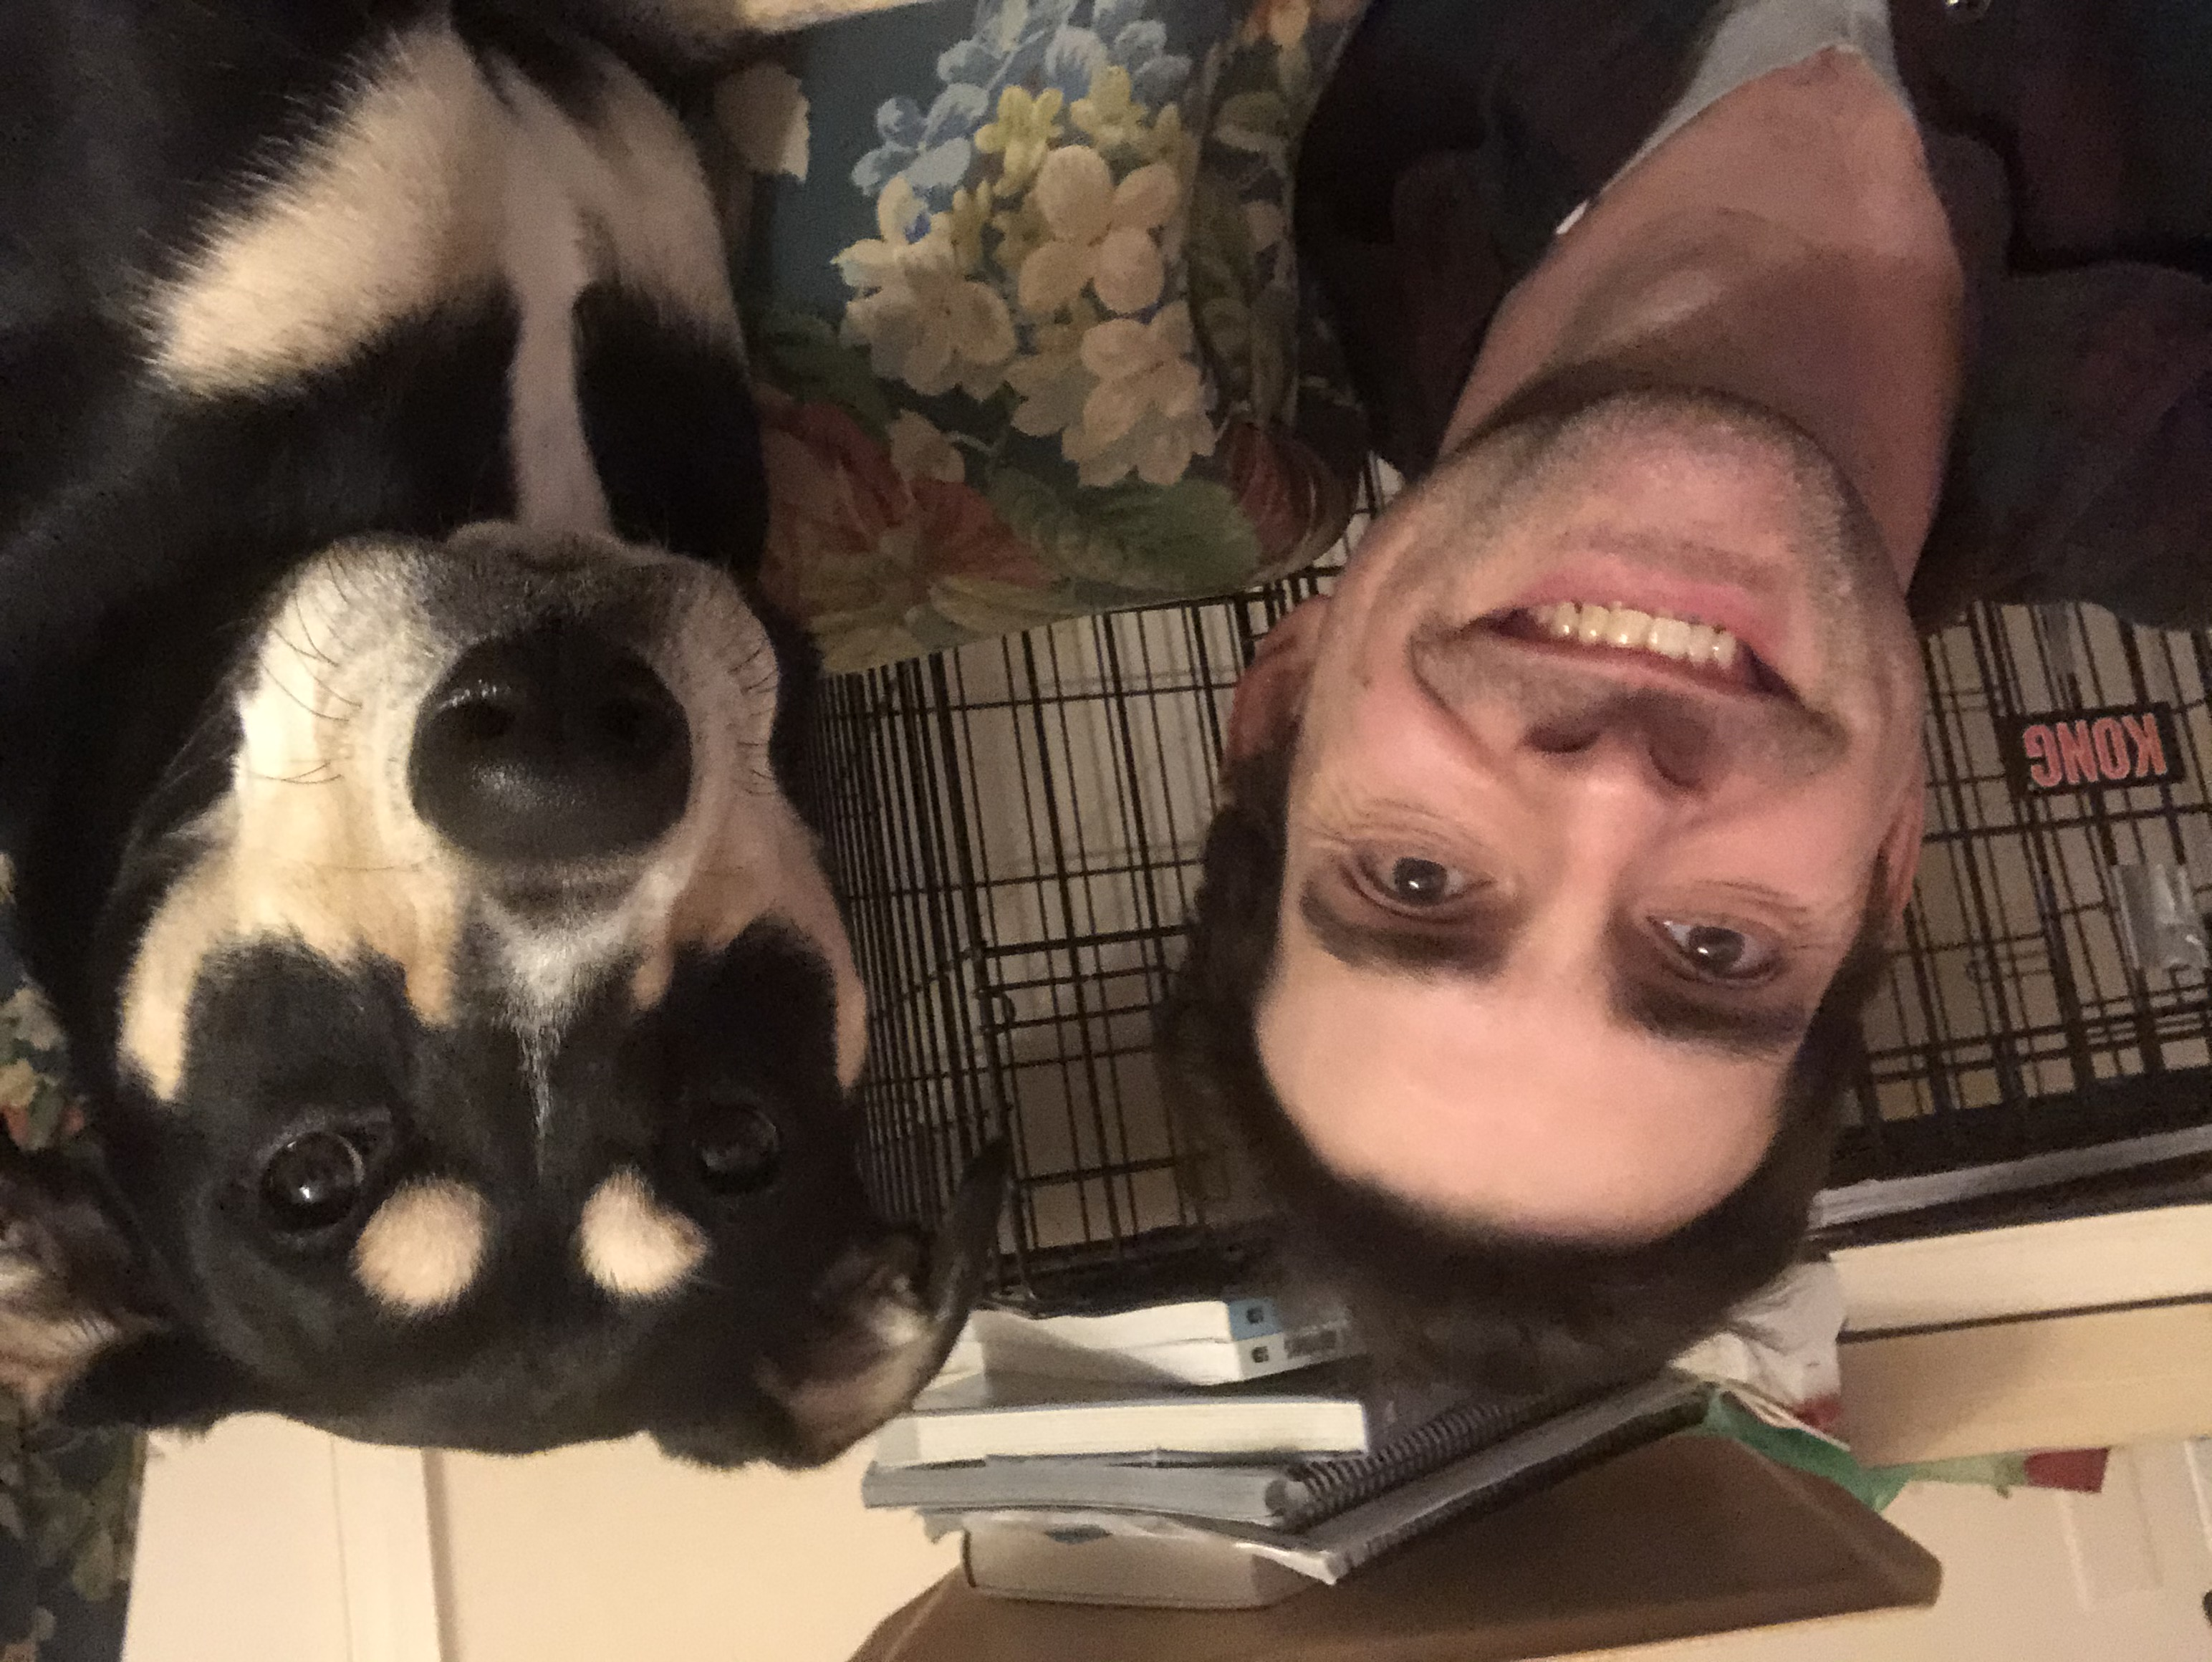

In [40]:
def get_sample(condition):   
    files = (
        pd.read_parquet(results_file)
        .query(condition)
        .sample(1)
        .path
    )
    for f in files:
        print(f)
        show(f)

get_sample(''' me==1 ''')


/mnt/4C74F47B74F468DA/Pictures/DSC_0008-2015-05-06 215914.JPG


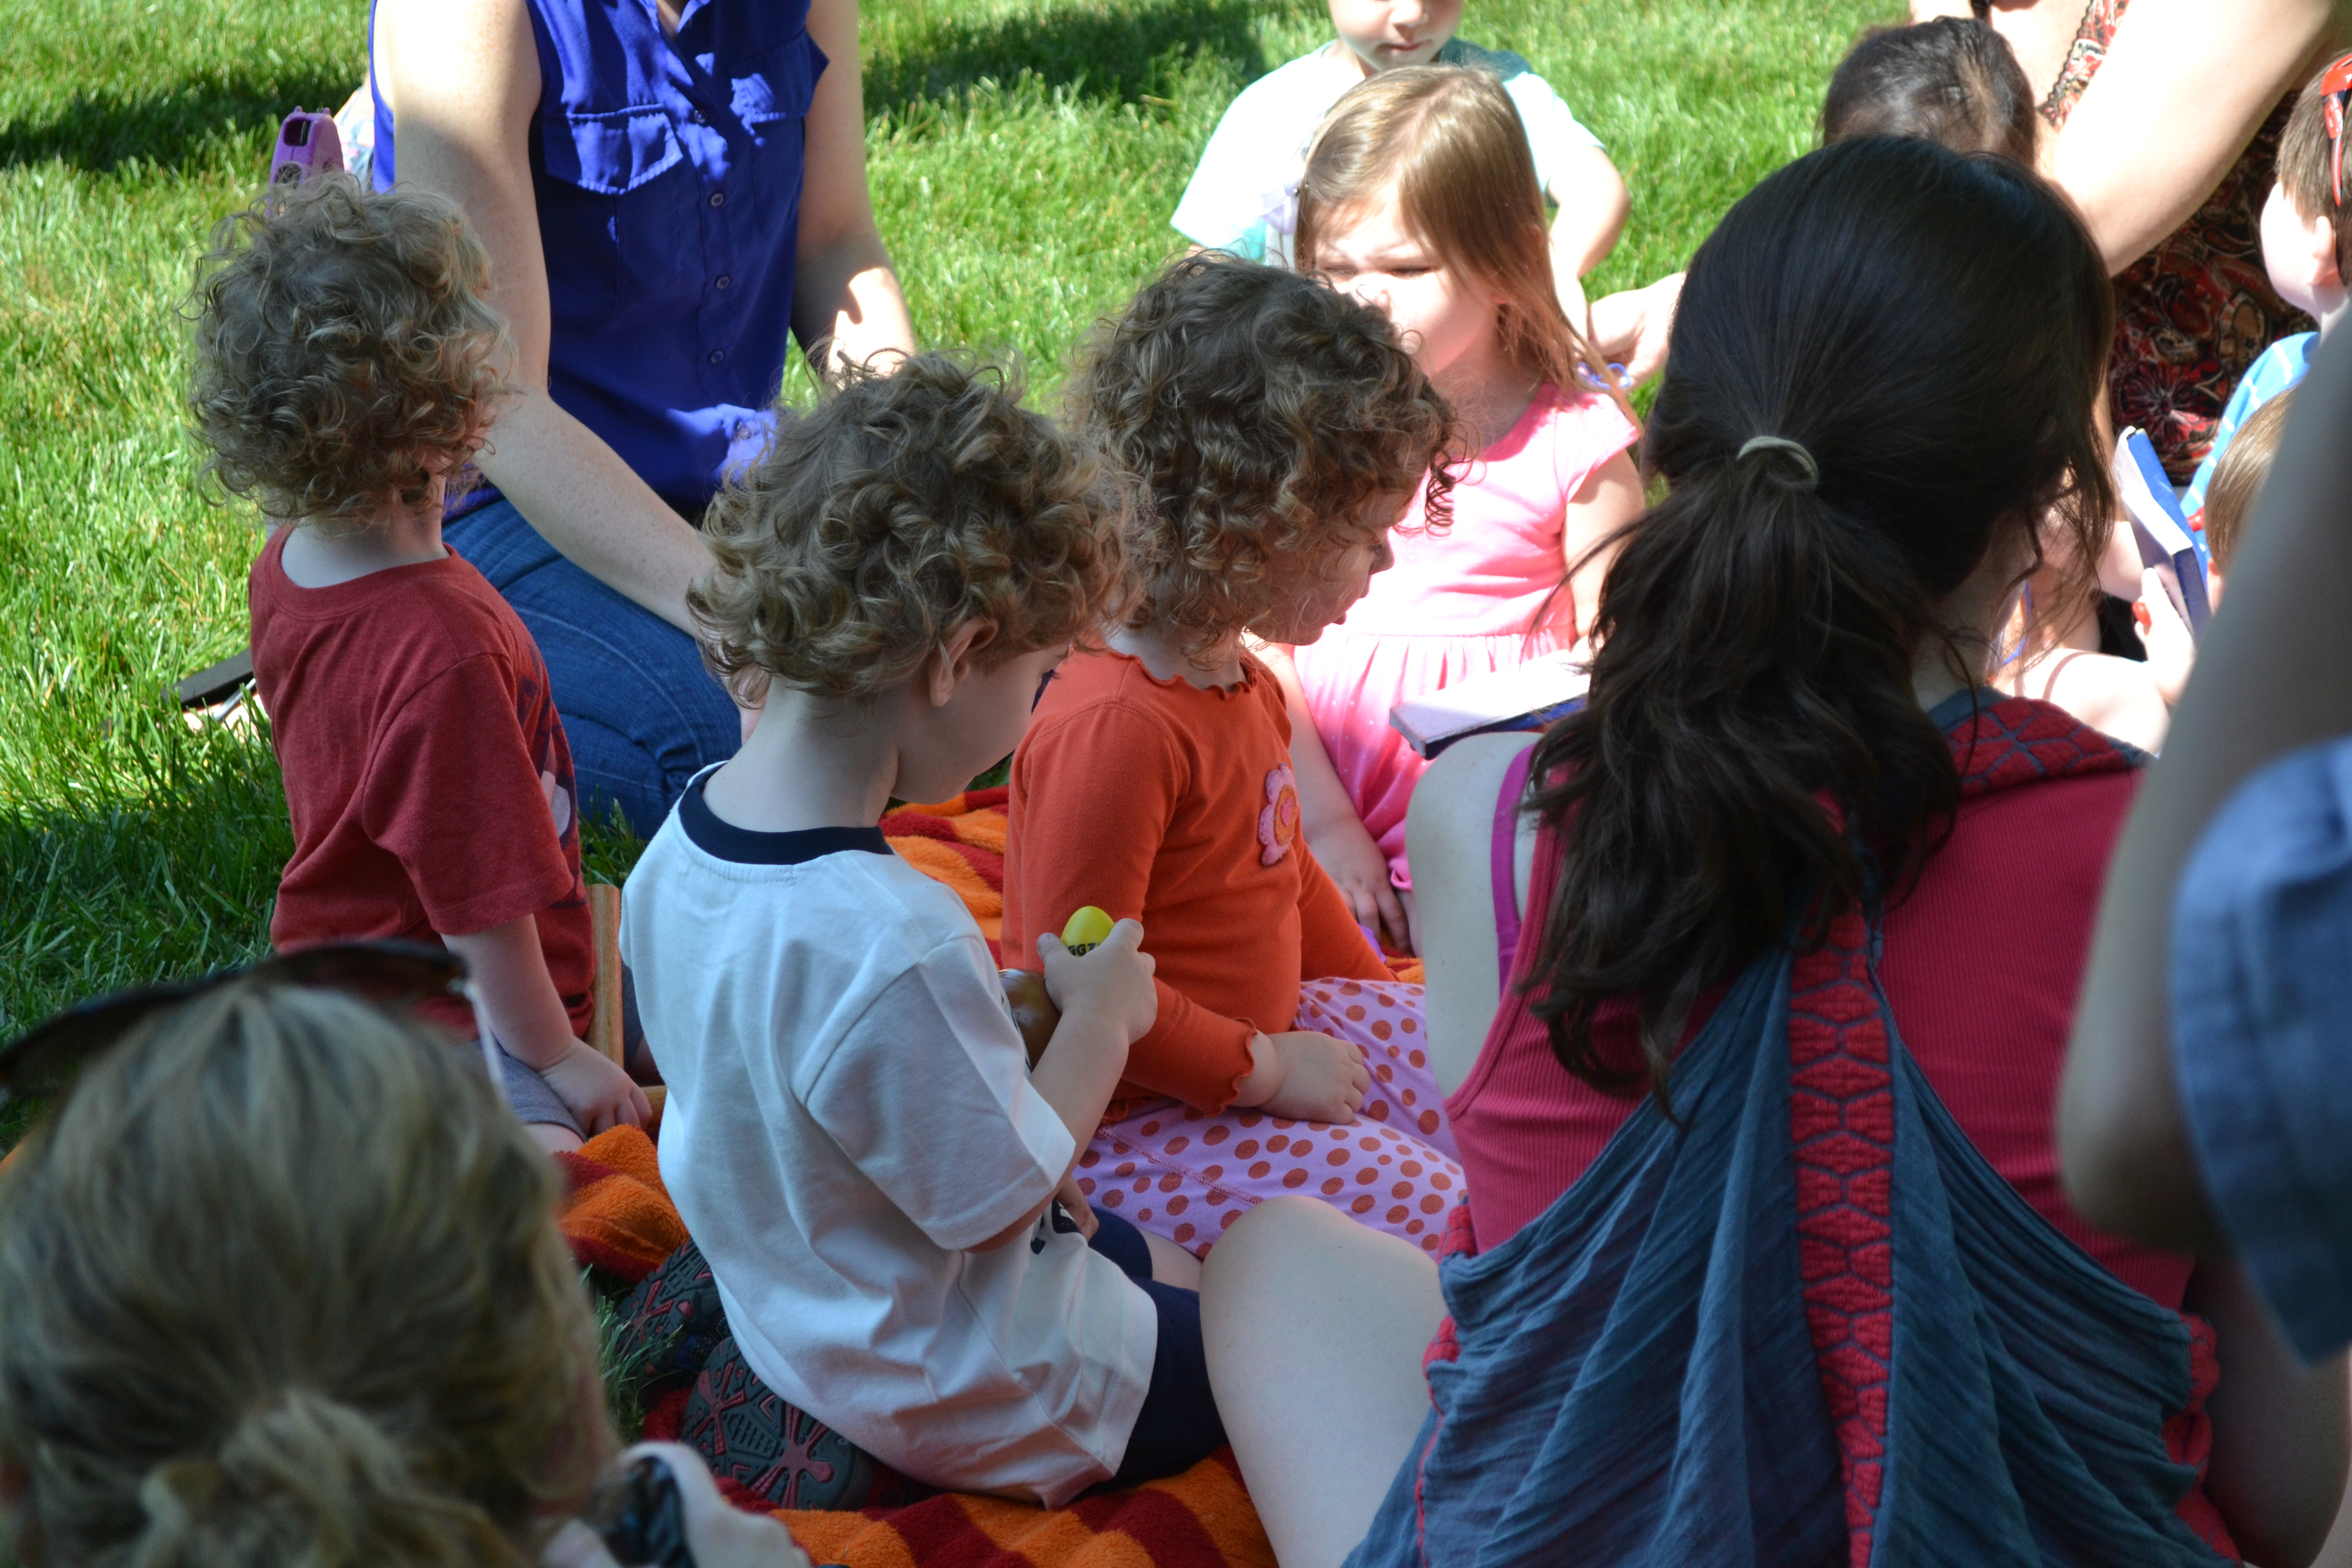

In [ ]:
# requires face forward
get_sample(''' wife==0 and daughter==0 and son==0 and me==0 ''')